In [7]:
import numpy as np
import tkinter as tk
from tkinter import filedialog
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [8]:
a= np.load("250422_RG0087_LightOnSPVImagesProcessing-04.npy")

In [9]:
a.shape

(32, 64)

In [10]:
print(a)

[[0.19945264 0.19077301 0.19936085 ... 0.18413067 0.18930674 0.18466711]
 [0.17959356 0.19173741 0.18273354 ... 0.18197656 0.18428445 0.18518686]
 [0.18809795 0.18815398 0.19527793 ... 0.18541694 0.1824367  0.18518567]
 ...
 [0.24037004 0.24173379 0.23225546 ... 0.23662567 0.2398324  0.23657203]
 [0.24501443 0.23840904 0.24758101 ... 0.24243474 0.24590611 0.24583101]
 [0.25959969 0.25807738 0.26130915 ... 0.25420547 0.26370049 0.26795268]]


In [11]:
np.flipud(a)

array([[0.25959969, 0.25807738, 0.26130915, ..., 0.25420547, 0.26370049,
        0.26795268],
       [0.24501443, 0.23840904, 0.24758101, ..., 0.24243474, 0.24590611,
        0.24583101],
       [0.24037004, 0.24173379, 0.23225546, ..., 0.23662567, 0.2398324 ,
        0.23657203],
       ...,
       [0.18809795, 0.18815398, 0.19527793, ..., 0.18541694, 0.1824367 ,
        0.18518567],
       [0.17959356, 0.19173741, 0.18273354, ..., 0.18197656, 0.18428445,
        0.18518686],
       [0.19945264, 0.19077301, 0.19936085, ..., 0.18413067, 0.18930674,
        0.18466711]])

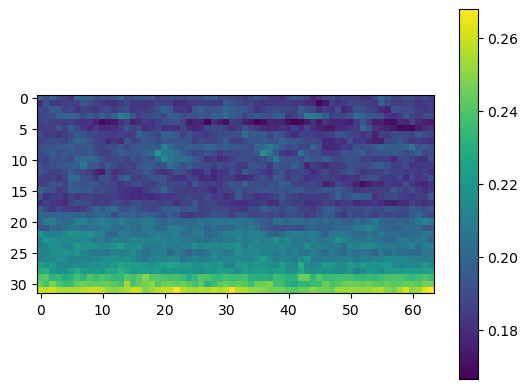

In [12]:
plt.imshow(a)
plt.colorbar()

In [13]:
#Single Gaussian Fitting function: 
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2*sigma**2))

In [14]:
mus = []
sigmas = []
scales = []
for i in range(a.shape[0]):
    x_data,voltage = np.histogram(a[i,:], bins='auto')
    #y_data = np.arange(x_data.shape[0])
    popt, pcov = curve_fit(gaussian, voltage[:-1],x_data, maxfev=100000000)
    scales.append(popt[0])
    mus.append(popt[1])
    sigmas.append(pcov[1,1])



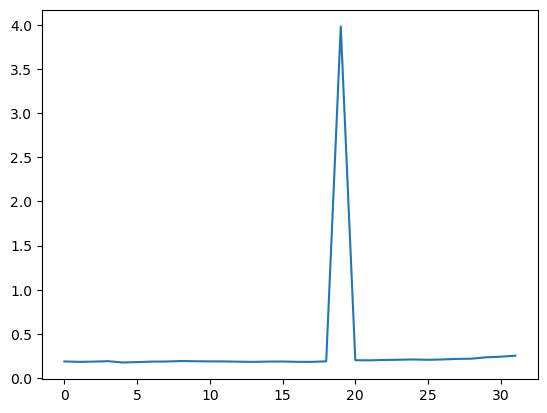

In [15]:
plt.plot(range(a.shape[0]),mus)

In [16]:
print(f"mu: {mus[-1]:.4},sigma: {sigmas[-1]:.4}")
#bin 14 mu: 0.2536,sigma: 5.85e-07
#bin 8 mu: 0.2529,sigma: 5.492e-07
#bin 20 mu: 0.2538,sigma: 8.041e-07
#bin 32 mu: 0.2541,sigma: 8.072e-07
#bin 4 mu: 0.2515,sigma: 1.795e-06
#bin 60 mu: 0.2543,sigma: 7.136e-07

mu: 0.2529,sigma: 5.492e-07


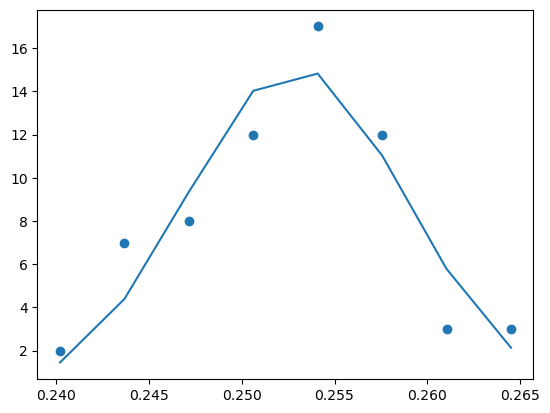

In [17]:
plt.scatter(voltage[:-1],x_data)
plt.plot(voltage[:-1], gaussian(voltage[:-1],*popt))

In [18]:
plt.scatter(x_data,y_data)
print(x_data.mean())
print(x_data.std())

#plt.plot(x_data, gaussian(x_data,*popt))

NameError: name 'y_data' is not defined

In [ ]:
b = np.loadtxt("testfile.txt",encoding='utf-8')
print(b[:,0]-voltage[:-1])

In [ ]:
b[:,1]

In [ ]:
x_data

In [ ]:
print(6*7.89217)